# Stationarity Testing

## Purpose

This notebook evaluates whether the climate anomaly series satisfies stationarity assumptions required by classical time series forecasting models.

### Objectives

- Visual inspection of stationarity
- Augmented Dickey-Fuller (ADF) testing
- Differencing operations
- Re-testing stationarity
- Preparation for forecasting models

### Expected Outcome

Determine whether the climate series requires transformation prior to forecasting.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (14,6)

In [2]:
df = pd.read_csv("/content/monthly_csv.csv")

df["Date"] = pd.to_datetime(df["Date"])

climate = (
    df.groupby("Date")["Mean"]
      .mean()
      .reset_index()
)

climate = climate.sort_values("Date")

climate.set_index(
    "Date",
    inplace=True
)

climate.head()

,Mean
Date,
1880-01-06,-0.14955
1880-02-06,-0.16645
1880-03-06,-0.15785
1880-04-06,-0.15995
1880-05-06,-0.10690


Visual Inspection

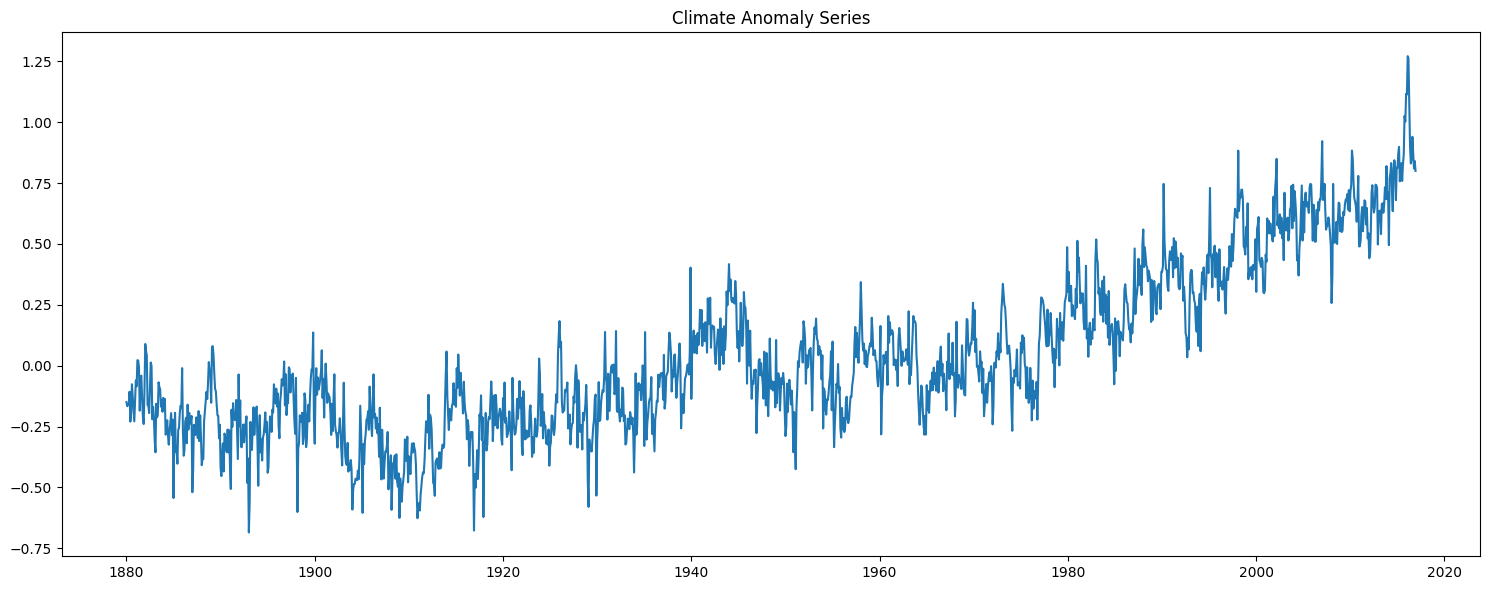

In [3]:
plt.figure(figsize=(15,6))

plt.plot(
    climate.index,
    climate["Mean"]
)

plt.title(
    "Climate Anomaly Series"
)

plt.tight_layout()

plt.savefig(
    "stationarity_visual_check.png",
    dpi=300
)

plt.show()

ADF Test

In [4]:
adf_result = adfuller(
    climate["Mean"]
)

print("ADF Statistic:", adf_result[0])

print("P-Value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(key, ":", value)

ADF Statistic: -0.4253688540073057
P-Value: 0.9057761439235836

Critical Values:
1% : -3.434395520959224
5% : -2.8633268625511046
10% : -2.5677212878453477


### ADF Decision Rule

H₀: Series is non-stationary

H₁: Series is stationary

If p-value < 0.05:

Reject H₀

The series is stationary.

First Differencing

In [5]:
climate["Difference_1"] = (
    climate["Mean"]
    .diff()
)

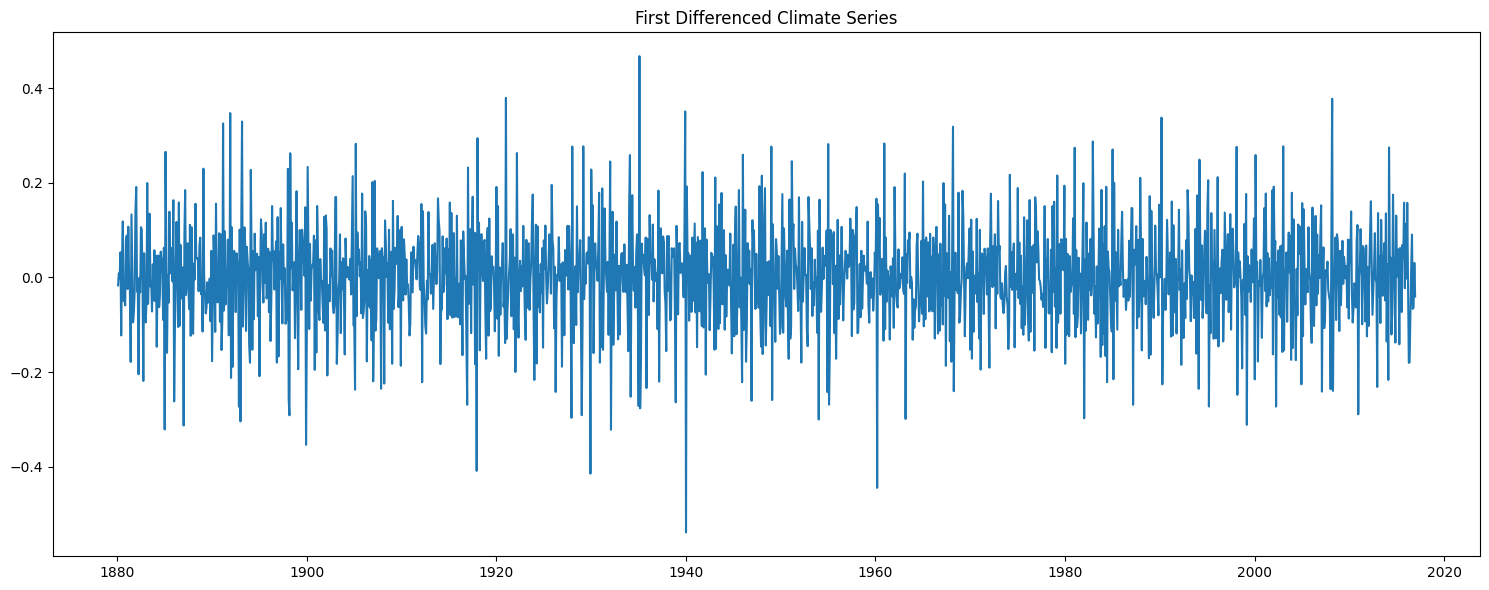

In [6]:
plt.figure(figsize=(15,6))

plt.plot(
    climate.index,
    climate["Difference_1"]
)

plt.title(
    "First Differenced Climate Series"
)

plt.tight_layout()

plt.savefig(
    "first_difference_series.png",
    dpi=300
)

plt.show()

ADF After Differencing

In [7]:
diff_series = climate[
    "Difference_1"
].dropna()

adf_diff = adfuller(
    diff_series
)

print("ADF Statistic:", adf_diff[0])

print("P-Value:", adf_diff[1])

ADF Statistic: -11.934591888141615
P-Value: 4.694696592248298e-22


Comparison Table

In [8]:
results = pd.DataFrame({
    "Series":[
        "Original",
        "First Difference"
    ],
    "ADF Statistic":[
        adf_result[0],
        adf_diff[0]
    ],
    "P-Value":[
        adf_result[1],
        adf_diff[1]
    ]
})

results

,Series,ADF Statistic,P-Value
0,Original,-0.425369,9.057761e-01
1,First Difference,-11.934592,4.694697e-22
